# Test model

In [16]:
model = "src\\plume\\best_full_checkpoint.pt"

### 1 — Imports & Model Architecture

In [17]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── ConvLSTM cell ─────────────────────────────────────────────────────────────
class ConvLSTMCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, kernel_size=3):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.gates = nn.Conv2d(
            input_channels + hidden_channels,
            4 * hidden_channels,
            kernel_size,
            padding=kernel_size // 2,
        )

    def forward(self, x, state):
        h, c = state
        i, f, g, o = self.gates(torch.cat([x, h], dim=1)).chunk(4, dim=1)
        c = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h = torch.sigmoid(o) * torch.tanh(c)
        return h, c

    def init_hidden(self, batch, height, width, device):
        z = torch.zeros(batch, self.hidden_channels, height, width, device=device)
        return z, z.clone()


# ── Full autoregressive forecaster (matches best_full_checkpoint.pt) ──────────
class AutoregressiveConvLSTMForecaster(nn.Module):
    def __init__(self, input_channels=10, encoder_channels=32, hidden_channels=64,
                 num_encoder_lstm_layers=2, decoder_channels=32, kernel_size=3,
                 groupnorm_groups=4, output_activation='softplus', future_steps=4):
        super().__init__()
        self.future_steps = future_steps

        self.encoder = nn.Sequential(
            nn.Conv2d(input_channels, encoder_channels, kernel_size, padding=kernel_size // 2),
            nn.GroupNorm(groupnorm_groups, encoder_channels),
            nn.ReLU(),
        )

        lstm_in = [encoder_channels] + [hidden_channels] * (num_encoder_lstm_layers - 1)
        self.encoder_lstm_layers = nn.ModuleList([
            ConvLSTMCell(inc, hidden_channels, kernel_size) for inc in lstm_in
        ])

        self.decoder_cell = ConvLSTMCell(1, hidden_channels, kernel_size)

        act = nn.Softplus() if output_activation == 'softplus' else nn.ReLU()
        self.decoder = nn.Sequential(
            nn.Conv2d(hidden_channels, decoder_channels, kernel_size, padding=kernel_size // 2),
            nn.GroupNorm(groupnorm_groups, decoder_channels),
            nn.ReLU(),
            nn.Conv2d(decoder_channels, 1, 1),
            act,
        )

    def forward(self, x):
        # x: (B, T_in, C, H, W)
        B, T_in, _, H, W = x.shape
        device = x.device

        states = [layer.init_hidden(B, H, W, device) for layer in self.encoder_lstm_layers]
        for t in range(T_in):
            h_in = self.encoder(x[:, t])
            for i, layer in enumerate(self.encoder_lstm_layers):
                h_in, c = layer(h_in, states[i])
                states[i] = (h_in, c)

        dec_h, dec_c = states[-1]
        prev_plume = x[:, -1, 0:1]   # last input frame, plume channel

        preds = []
        for _ in range(self.future_steps):
            dec_h, dec_c = self.decoder_cell(prev_plume, (dec_h, dec_c))
            out = self.decoder(dec_h)   # (B, 1, H, W)
            preds.append(out)
            prev_plume = out

        return torch.stack(preds, dim=1)  # (B, T_out, 1, H, W)

print("Model classes defined.")

Model classes defined.


### 2 — Load Checkpoint

In [18]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Resolve checkpoint path whether notebook runs from project root or EDA/
ckpt_path = Path(model)
if not ckpt_path.exists():
    ckpt_path = Path('..') / model
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
cfg  = ckpt['config']
m    = cfg['model']
d    = cfg['data']

net = AutoregressiveConvLSTMForecaster(
    input_channels          = d['input_channels'],
    encoder_channels        = m['encoder_channels'],
    hidden_channels         = m['hidden_channels'],
    num_encoder_lstm_layers = m['num_encoder_lstm_layers'],
    decoder_channels        = m['decoder_channels'],
    kernel_size             = m['kernel_size'],
    groupnorm_groups        = m['groupnorm_groups'],
    output_activation       = m['output_activation'],
    future_steps            = d['future_steps'],
)
net.load_state_dict(ckpt['model_state_dict'])
net.to(device).eval()

metrics = ckpt['metrics']
print(f"Checkpoint loaded  |  epoch {int(metrics['global_epoch'])}  |  stage: {ckpt['stage_name']}")
print(f"  Val MSE : {metrics['val_mse']:.5f}")
print(f"  Val MAE : {metrics['val_mae']:.5f}")
print(f"  Val IoU : {metrics['val_plume_iou']:.4f}")
print(f"  Device  : {device}")

Checkpoint loaded  |  epoch 11  |  stage: stage1_data_only
  Val MSE : 0.29247
  Val MAE : 0.31491
  Val IoU : 0.3305
  Device  : cuda


### 3 — Load Mock Data & Run Inference

In [19]:
N_SAMPLES = 50   # how many windows to test on
random.seed(42)

# Resolve data directory
data_dir = Path('EDA/data/windows')
if not data_dir.exists():
    data_dir = Path('data/windows')
assert data_dir.exists(), f"Data directory not found: {data_dir}"

all_files  = sorted(data_dir.glob('*.npz'))
test_files = random.sample(all_files, min(N_SAMPLES, len(all_files)))
print(f"Using {len(test_files)} / {len(all_files)} windows from {data_dir}")

inputs_list, targets_list, targets_all_list = [], [], []
for fp in test_files:
    d = np.load(fp)
    inputs_list.append(d['input'].astype(np.float32))              # (3, 10, 64, 64)
    targets_list.append(d['target'][0, 0].astype(np.float32))      # (64, 64) step-1 plume
    targets_all_list.append(d['target'][:, 0].astype(np.float32))  # (4, 64, 64) all steps

inputs_np      = np.stack(inputs_list)       # (N, 3, 10, 64, 64)
targets_np     = np.stack(targets_list)      # (N, 64, 64)     — step-1, used by metrics
targets_all_np = np.stack(targets_all_list)  # (N, 4, 64, 64)  — all future steps

# Batch inference — keep all 4 predicted future steps
BATCH = 16
all_preds      = []
all_preds_full = []
inputs_t = torch.from_numpy(inputs_np)

with torch.no_grad():
    for start in range(0, len(inputs_t), BATCH):
        batch = inputs_t[start:start + BATCH].to(device)
        out   = net(batch)                                  # (B, 4, 1, 64, 64)
        all_preds.append(out[:, 0, 0].cpu().numpy())       # step-1:    (B, 64, 64)
        all_preds_full.append(out[:, :, 0].cpu().numpy())  # all steps: (B, 4, 64, 64)

preds_np     = np.concatenate(all_preds, axis=0)       # (N, 64, 64)    — step-1
preds_all_np = np.concatenate(all_preds_full, axis=0)  # (N, 4, 64, 64) — all steps

print(f"Inference done.")
print(f"  Future steps      : {preds_all_np.shape[1]}")
print(f"  Prediction range (step-1) : [{preds_np.min():.5f},  {preds_np.max():.5f}]")
print(f"  Target range    (step-1)  : [{targets_np.min():.5f},  {targets_np.max():.5f}]")

Using 50 / 40215 windows from data\windows
Inference done.
  Future steps      : 4
  Prediction range (step-1) : [0.00002,  3.20273]
  Target range    (step-1)  : [0.00000,  6.87833]


### 4 — MSE Validation Metrics

In [20]:
pred_flat   = preds_np.flatten()
target_flat = targets_np.flatten()

mse_global  = mean_squared_error(target_flat, pred_flat)
rmse_global = np.sqrt(mse_global)
mae_global  = mean_absolute_error(target_flat, pred_flat)

# Plume-only region (non-background pixels)
plume_mask  = target_flat > 1e-6
mse_plume   = mean_squared_error(target_flat[plume_mask], pred_flat[plume_mask]) if plume_mask.any() else np.nan
rmse_plume  = np.sqrt(mse_plume)
mae_plume   = mean_absolute_error(target_flat[plume_mask], pred_flat[plume_mask]) if plume_mask.any() else np.nan

# Per-sample peak relative error
peak_tgt = targets_np.max(axis=(1, 2))
peak_prd = preds_np.max(axis=(1, 2))
peak_rel = np.abs(peak_prd - peak_tgt) / (peak_tgt + 1e-10)

# Per-sample MSE distribution
per_sample_mse = np.array([
    mean_squared_error(targets_np[i].flatten(), preds_np[i].flatten())
    for i in range(len(preds_np))
])

print("=" * 52)
print("  VALIDATION METRICS  (step-1 plume prediction)")
print("=" * 52)
print(f"  Samples evaluated   : {len(preds_np)}")
print()
print(f"  ── Global (all pixels) ──────────────────────")
print(f"  MSE                 : {mse_global:.6f}")
print(f"  RMSE                : {rmse_global:.6f}")
print(f"  MAE                 : {mae_global:.6f}")
print()
print(f"  ── Plume region only (concentration > 1e-6) ─")
print(f"  MSE                 : {mse_plume:.6f}")
print(f"  RMSE                : {rmse_plume:.6f}")
print(f"  MAE                 : {mae_plume:.6f}")
print(f"  Plume pixel share   : {plume_mask.mean()*100:.1f}%")
print()
print(f"  ── Per-sample stats ─────────────────────────")
print(f"  MSE  mean ± std     : {per_sample_mse.mean():.6f} ± {per_sample_mse.std():.6f}")
print(f"  MSE  median         : {np.median(per_sample_mse):.6f}")
print(f"  Peak rel-error mean : {peak_rel.mean():.4f}")
print("=" * 52)

  VALIDATION METRICS  (step-1 plume prediction)
  Samples evaluated   : 50

  ── Global (all pixels) ──────────────────────
  MSE                 : 0.939787
  RMSE                : 0.969426
  MAE                 : 0.583993

  ── Plume region only (concentration > 1e-6) ─
  MSE                 : 2.339285
  RMSE                : 1.529472
  MAE                 : 1.051615
  Plume pixel share   : 35.1%

  ── Per-sample stats ─────────────────────────
  MSE  mean ± std     : 0.939787 ± 0.840149
  MSE  median         : 0.609970
  Peak rel-error mean : 0.5839


### 5 — Prediction vs Ground Truth Plots

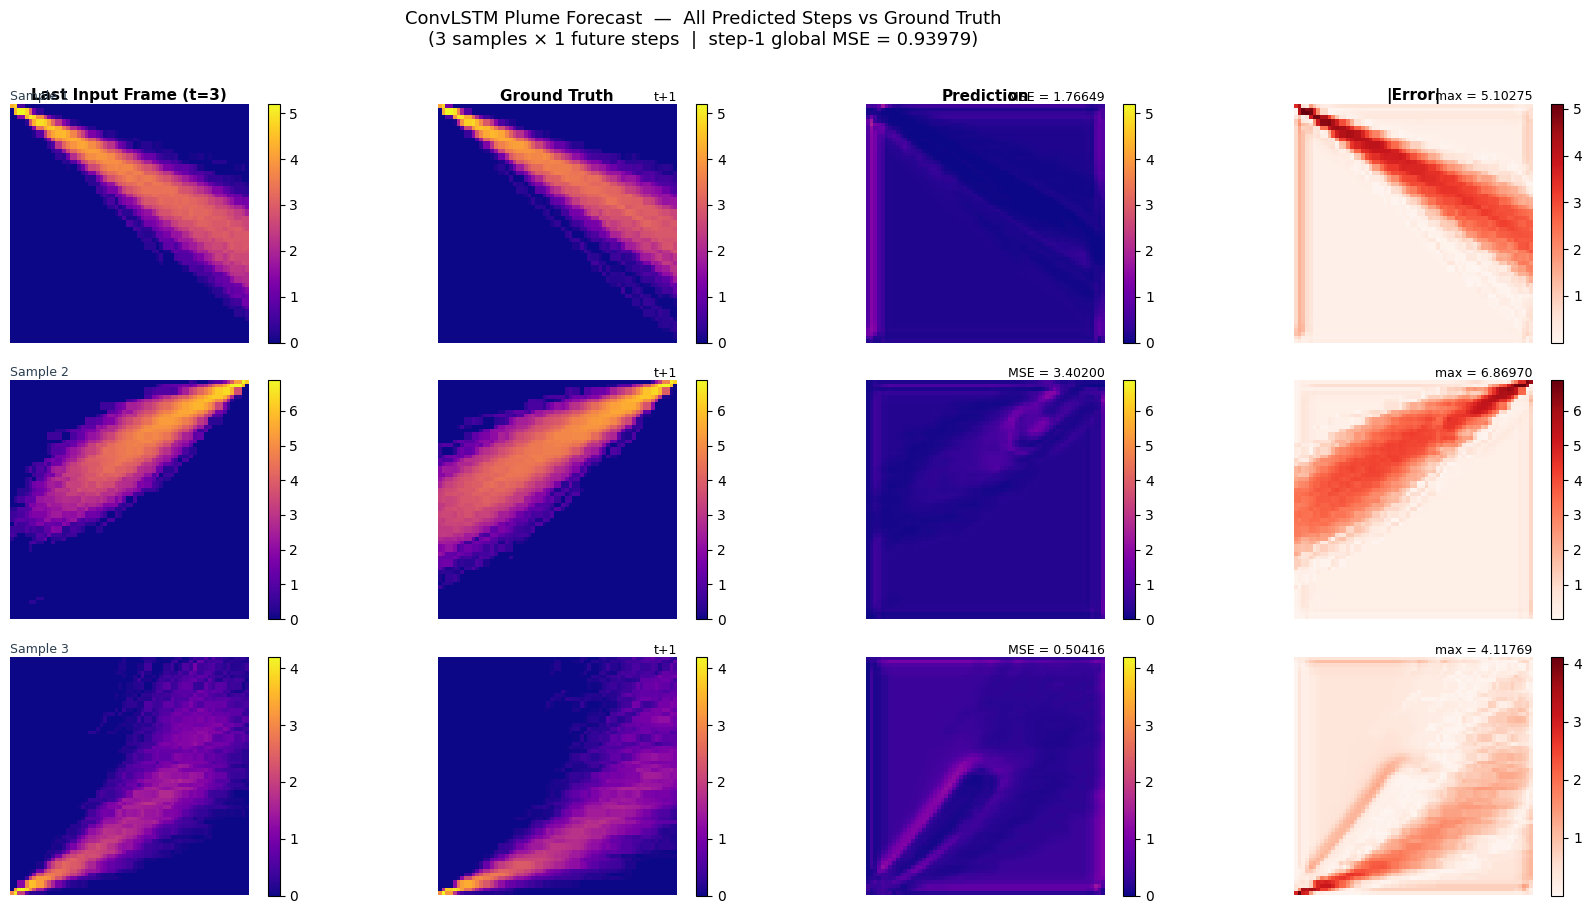

Plot saved → model_predictions_vs_actual.png


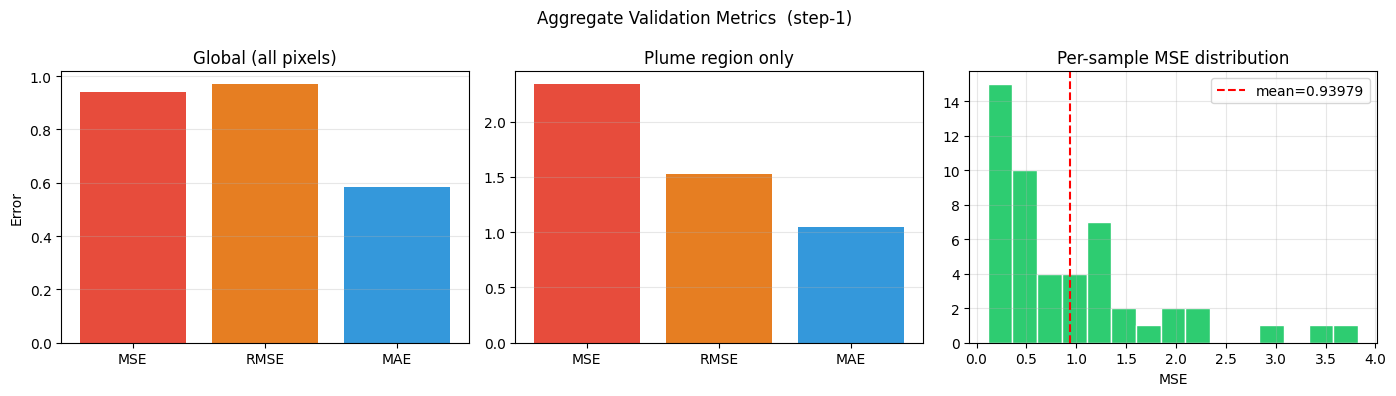

In [21]:
N_VIS = 3
random.seed(7)

# Ensure preds_all_np exists (fallback to preds_np if only step-1 preds are available)
if 'preds_all_np' not in globals():
	if 'preds_np' in globals():
		preds_all_np = preds_np[:, None, ...]   # make shape (N, 1, H, W)
	else:
		raise NameError("preds_all_np not found. Run the inference cell first (it defines preds_all_np or preds_np).")

# Ensure targets_all_np exists (fallback to targets_np if only step-1 targets are available)
if 'targets_all_np' not in globals():
	if 'targets_np' in globals():
		targets_all_np = targets_np[:, None, ...]   # make shape (N, 1, H, W)
	else:
		raise NameError("targets_all_np not found. Run the inference cell first (it defines targets_all_np or targets_np).")

FUTURE_STEPS = min(preds_all_np.shape[1], targets_all_np.shape[1])
N_VIS = min(N_VIS, len(preds_all_np))
vis_idx = random.sample(range(len(preds_all_np)), N_VIS)

n_rows = N_VIS * FUTURE_STEPS
fig, axes = plt.subplots(n_rows, 4, figsize=(18, n_rows * 3), squeeze=False)
fig.suptitle(
    "ConvLSTM Plume Forecast  —  All Predicted Steps vs Ground Truth\n"
    f"({N_VIS} samples × {FUTURE_STEPS} future steps  |  step-1 global MSE = {mse_global:.5f})",
    fontsize=13, y=1.01,
)

# Column headers on the very first row
col_labels = ["Last Input Frame (t=3)", "Ground Truth", "Prediction", "|Error|"]
for ax, lbl in zip(axes[0], col_labels):
    ax.set_title(lbl, fontsize=11, fontweight='bold')

for s, idx in enumerate(vis_idx):
    inp        = inputs_np[idx]   # (3, 10, 64, 64)
    last_frame = inp[-1, 0]       # (64, 64) — last input plume channel

    for step in range(FUTURE_STEPS):
        row  = s * FUTURE_STEPS + step
        pred = preds_all_np[idx, step]    # (64, 64)
        tgt  = targets_all_np[idx, step]  # (64, 64)
        err  = np.abs(pred - tgt)
        vmax = max(float(pred.max()), float(tgt.max()), 1e-8)
        step_mse = mean_squared_error(tgt.flatten(), pred.flatten())

        # ── Col 0: last input frame (first step of each sample only) ──────
        if step == 0:
            im = axes[row, 0].imshow(last_frame, cmap='plasma', vmin=0, vmax=vmax)
            plt.colorbar(im, ax=axes[row, 0], fraction=0.046, pad=0.04)
            axes[row, 0].set_title(f"Sample {s + 1}", loc='left',
                                   fontsize=9, color='#2c3e50', pad=3)
        else:
            axes[row, 0].text(0.5, 0.5, "↑ same input", ha='center', va='center',
                              fontsize=9, color='gray',
                              transform=axes[row, 0].transAxes)

        # ── Col 1: ground truth ───────────────────────────────────────────
        im = axes[row, 1].imshow(tgt, cmap='plasma', vmin=0, vmax=vmax)
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
        axes[row, 1].set_title(f"t+{step + 1}", loc='right', fontsize=9, pad=2)

        # ── Col 2: prediction ─────────────────────────────────────────────
        im = axes[row, 2].imshow(pred, cmap='plasma', vmin=0, vmax=vmax)
        plt.colorbar(im, ax=axes[row, 2], fraction=0.046, pad=0.04)
        axes[row, 2].set_title(f"MSE = {step_mse:.5f}", loc='right', fontsize=9, pad=2)

        # ── Col 3: absolute error ─────────────────────────────────────────
        im = axes[row, 3].imshow(err, cmap='Reds')
        plt.colorbar(im, ax=axes[row, 3], fraction=0.046, pad=0.04)
        axes[row, 3].set_title(f"max = {err.max():.5f}", loc='right', fontsize=9, pad=2)

        for ax in axes[row]:
            ax.axis('off')

plt.tight_layout()
out_path = Path('EDA/model_predictions_vs_actual.png')
if not out_path.parent.exists():
    out_path = Path('model_predictions_vs_actual.png')
plt.savefig(out_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Plot saved → {out_path}")

# ── Aggregate metrics bar chart ───────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
fig2.suptitle("Aggregate Validation Metrics  (step-1)", fontsize=12)

axes2[0].bar(['MSE', 'RMSE', 'MAE'],
             [mse_global, rmse_global, mae_global],
             color=['#e74c3c', '#e67e22', '#3498db'])
axes2[0].set_title("Global (all pixels)")
axes2[0].set_ylabel("Error")
axes2[0].grid(axis='y', alpha=0.3)

axes2[1].bar(['MSE', 'RMSE', 'MAE'],
             [mse_plume, rmse_plume, mae_plume],
             color=['#e74c3c', '#e67e22', '#3498db'])
axes2[1].set_title("Plume region only")
axes2[1].grid(axis='y', alpha=0.3)

axes2[2].hist(per_sample_mse, bins=15, color='#2ecc71', edgecolor='white')
axes2[2].axvline(per_sample_mse.mean(), color='red', linestyle='--',
                 label=f"mean={per_sample_mse.mean():.5f}")
axes2[2].set_title("Per-sample MSE distribution")
axes2[2].set_xlabel("MSE")
axes2[2].legend()
axes2[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(out_path.with_name('model_metrics_summary.png'), dpi=120, bbox_inches='tight')
plt.show()

### 6 — Physics-Based Evaluation

The model was trained exclusively in **stage 1 (data-only)** — all physics loss weights (`mass`, `smooth`, `nonneg`, `bg`, `advect`) were set to **0.0**.  
This section measures how well the predictions obey physical plume behaviour *without* having been penalised for it:

| Metric | What it measures |
|---|---|
| **Mass conservation** | Total predicted concentration vs target per future step |
| **Peak location error** | Pixel distance between predicted and actual plume peak |
| **Centroid error** | Weighted-centroid displacement (plume tracking accuracy) |
| **Spatial spread ratio** | Whether the model replicates the physical dispersion radius |
| **Background false-positive rate** | Spurious concentration in clean-air regions |
| **Plume IoU** | Overlap of predicted vs true plume footprint |
| **Laplacian smoothness** | Physical plumes are smooth — high Laplacian → unphysical sharp edges |
| **Non-negativity** | Softplus output should guarantee zero negative values |

In [22]:
from scipy.ndimage import laplace

PLUME_THRESHOLD = 1e-6
n_steps     = min(preds_all_np.shape[1], targets_all_np.shape[1])  # guard against shape mismatch
step_labels = [f"t+{s+1}" for s in range(n_steps)]
N           = len(preds_all_np)
H, W        = preds_all_np.shape[2], preds_all_np.shape[3]
yy, xx      = np.mgrid[0:H, 0:W]

mass_pred    = np.zeros((N, n_steps))
mass_tgt     = np.zeros((N, n_steps))
lap_pred     = np.zeros((N, n_steps))
lap_tgt      = np.zeros((N, n_steps))
peak_loc_err = np.zeros((N, n_steps))
peak_val_err = np.zeros((N, n_steps))
bg_fp_rate   = np.zeros((N, n_steps))
iou_steps    = np.zeros((N, n_steps))
spread_pred  = np.zeros((N, n_steps))
spread_tgt   = np.zeros((N, n_steps))
centroid_err = np.zeros((N, n_steps))

for i in range(N):
    for s in range(n_steps):
        p = preds_all_np[i, s]
        t = targets_all_np[i, s]

        # 1. Mass (sum of concentration over the grid)
        mass_pred[i, s] = p.sum()
        mass_tgt[i, s]  = t.sum()

        # 2. Laplacian smoothness — physical plumes have small Laplacian
        lap_pred[i, s] = np.abs(laplace(p)).mean()
        lap_tgt[i, s]  = np.abs(laplace(t)).mean()

        # 3. Peak location error (Euclidean pixels)
        p_idx = np.unravel_index(p.argmax(), p.shape)
        t_idx = np.unravel_index(t.argmax(), t.shape)
        peak_loc_err[i, s] = np.hypot(p_idx[0] - t_idx[0], p_idx[1] - t_idx[1])

        # 4. Peak value relative error
        peak_val_err[i, s] = abs(p.max() - t.max()) / (t.max() + 1e-10)

        # 5. Background false-positive rate
        bg_mask = t < PLUME_THRESHOLD
        if bg_mask.any():
            bg_fp_rate[i, s] = (p[bg_mask] >= PLUME_THRESHOLD).mean()

        # 6. Plume IoU
        pred_mask = p >= PLUME_THRESHOLD
        tgt_mask  = t >= PLUME_THRESHOLD
        inter = (pred_mask & tgt_mask).sum()
        union = (pred_mask | tgt_mask).sum()
        iou_steps[i, s] = inter / union if union > 0 else 0.0

        # 7. Spatial spread (mass-weighted std dev — dispersion radius in pixels)
        total_p = p.sum() + 1e-12
        cx_p = (p * xx).sum() / total_p;  cy_p = (p * yy).sum() / total_p
        spread_pred[i, s] = np.sqrt(((p * ((xx - cx_p)**2 + (yy - cy_p)**2)).sum()) / total_p)

        total_t = t.sum() + 1e-12
        cx_t = (t * xx).sum() / total_t;  cy_t = (t * yy).sum() / total_t
        spread_tgt[i, s]  = np.sqrt(((t * ((xx - cx_t)**2 + (yy - cy_t)**2)).sum()) / total_t)

        # 8. Centroid location error
        centroid_err[i, s] = np.hypot(cx_p - cx_t, cy_p - cy_t)

mass_rel_err   = np.abs(mass_pred - mass_tgt) / (mass_tgt + 1e-10)
laplacian_ratio = lap_pred / (lap_tgt + 1e-10)
spread_ratio    = spread_pred / (spread_tgt + 1e-10)

# ── Print summary table ────────────────────────────────────────────────────────
print("=" * 68)
print(f"  PHYSICS-BASED EVALUATION  ({n_steps} future steps, {N} test samples)")
print("=" * 68)
header = f"  {'Metric':<36}" + "  ".join(f"{l:>7}" for l in step_labels)
print(header)
print("  " + "-" * 64)

def row(name, arr):
    print(f"  {name:<36}" + "  ".join(f"{v:>7.4f}" for v in arr.mean(axis=0)))

row("Mass rel. error  (|pred−tgt|/tgt)", mass_rel_err)
row("Peak loc. error  (pixels)",          peak_loc_err)
row("Peak val. rel. error",               peak_val_err)
row("Background FP rate",                 bg_fp_rate)
row("Plume IoU",                          iou_steps)
row("Centroid error  (pixels)",           centroid_err)
row("Spread ratio  (pred / tgt)",         spread_ratio)
row("Laplacian ratio  (pred / tgt)",      laplacian_ratio)

print("\n  ── Mass balance (absolute totals, mean ± std) ─────────────────")
for s in range(n_steps):
    mp     = mass_pred[:, s].mean()
    mt     = mass_tgt[:, s].mean()
    mp_s   = mass_pred[:, s].std()
    mt_s   = mass_tgt[:, s].std()
    bias   = 100 * (mp - mt) / (mt + 1e-10)
    print(f"  {step_labels[s]}:  pred = {mp:7.1f} ± {mp_s:.1f}  |  tgt = {mt:7.1f} ± {mt_s:.1f}  |  bias = {bias:+.1f}%")

print("\n  ── Non-negativity check (softplus guarantee) ──────────────────")
print(f"  Min predicted value (all steps) : {preds_all_np.min():.2e}")
print(f"  Negative pixels                 : {(preds_all_np < 0).sum()}")
print("=" * 68)


  PHYSICS-BASED EVALUATION  (1 future steps, 50 test samples)
  Metric                                  t+1
  ----------------------------------------------------------------
  Mass rel. error  (|pred−tgt|/tgt)    0.6607
  Peak loc. error  (pixels)           19.9358
  Peak val. rel. error                 0.5839
  Background FP rate                   1.0000
  Plume IoU                            0.3508
  Centroid error  (pixels)            10.9023
  Spread ratio  (pred / tgt)           1.5693
  Laplacian ratio  (pred / tgt)        0.6903

  ── Mass balance (absolute totals, mean ± std) ─────────────────
  t+1:  pred =  1279.6 ± 561.3  |  tgt =  1764.9 ± 1036.0  |  bias = -27.5%

  ── Non-negativity check (softplus guarantee) ──────────────────
  Min predicted value (all steps) : 1.04e-08
  Negative pixels                 : 0


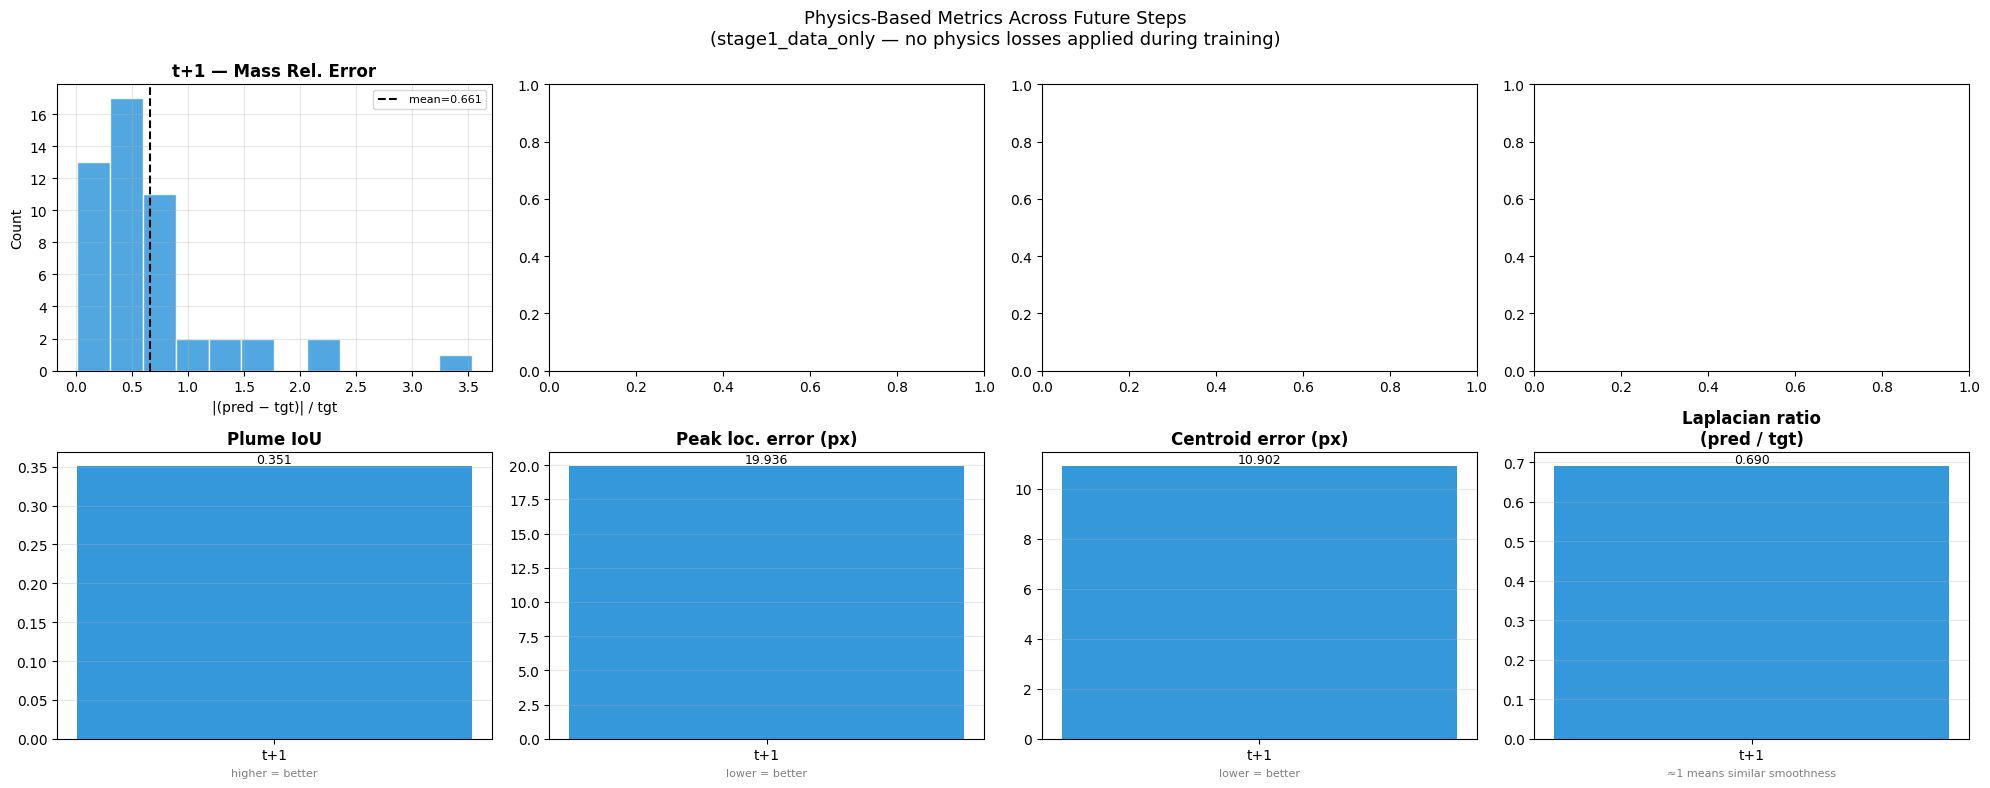

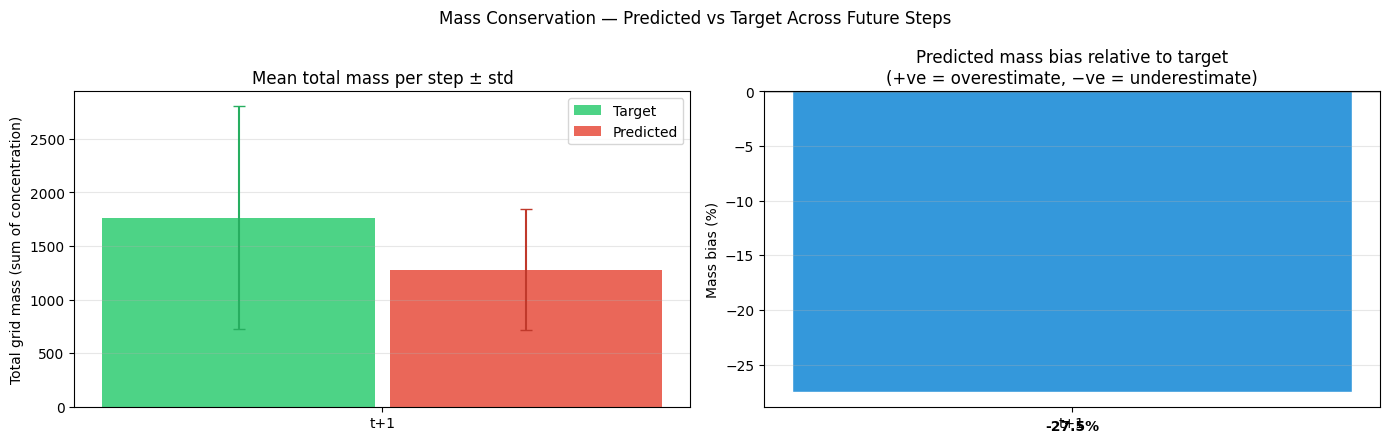

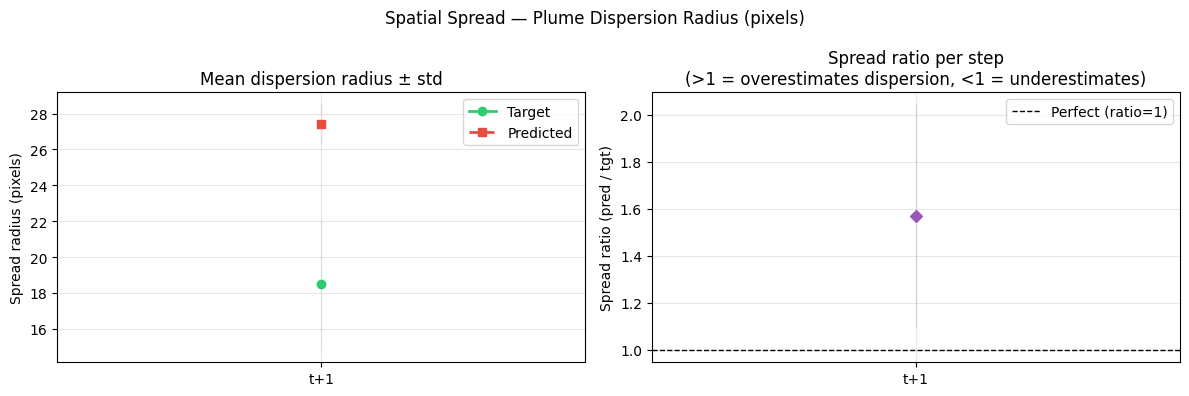

In [23]:
colors = ['#3498db', '#9b59b6', '#e67e22', '#e74c3c']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle(
    "Physics-Based Metrics Across Future Steps\n"
    "(stage1_data_only — no physics losses applied during training)",
    fontsize=13,
)

# ── Row 0: mass relative error histograms per step ────────────────────────────
for s in range(n_steps):
    ax = axes[0, s]
    ax.hist(mass_rel_err[:, s], bins=12, color=colors[s], edgecolor='white', alpha=0.85)
    ax.axvline(mass_rel_err[:, s].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f"mean={mass_rel_err[:, s].mean():.3f}")
    ax.set_title(f"{step_labels[s]} — Mass Rel. Error", fontweight='bold')
    ax.set_xlabel("|(pred − tgt)| / tgt")
    if s == 0:
        ax.set_ylabel("Count")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# ── Row 1: bar charts for IoU, peak loc error, centroid error, laplacian ratio ─
metrics_row1 = [
    ("Plume IoU",              iou_steps,       "higher = better"),
    ("Peak loc. error (px)",   peak_loc_err,    "lower = better"),
    ("Centroid error (px)",    centroid_err,    "lower = better"),
    ("Laplacian ratio\n(pred / tgt)", laplacian_ratio, "≈1 means similar smoothness"),
]

for col, (title, arr, note) in enumerate(metrics_row1):
    ax = axes[1, col]
    vals = arr.mean(axis=0)
    bars = ax.bar(step_labels, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(note, fontsize=8, color='gray')
    ax.grid(axis='y', alpha=0.3)
    for j, v in enumerate(vals):
        ax.text(j, v * 1.01 + 1e-4, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# ── Mass balance bar chart ─────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 4.5))
fig2.suptitle("Mass Conservation — Predicted vs Target Across Future Steps", fontsize=12)

mp_mean = mass_pred.mean(axis=0);  mp_std = mass_pred.std(axis=0)
mt_mean = mass_tgt.mean(axis=0);   mt_std = mass_tgt.std(axis=0)
x = np.arange(n_steps)

axes2[0].bar(x - 0.2, mt_mean, 0.38, label='Target',    color='#2ecc71', alpha=0.85)
axes2[0].bar(x + 0.2, mp_mean, 0.38, label='Predicted', color='#e74c3c', alpha=0.85)
axes2[0].errorbar(x - 0.2, mt_mean, yerr=mt_std, fmt='none', color='#27ae60', capsize=4)
axes2[0].errorbar(x + 0.2, mp_mean, yerr=mp_std, fmt='none', color='#c0392b', capsize=4)
axes2[0].set_xticks(x); axes2[0].set_xticklabels(step_labels)
axes2[0].set_ylabel("Total grid mass (sum of concentration)")
axes2[0].set_title("Mean total mass per step ± std")
axes2[0].legend(); axes2[0].grid(axis='y', alpha=0.3)

bias_pct = 100 * (mp_mean - mt_mean) / (mt_mean + 1e-10)
bar_colors = ['#e74c3c' if b > 0 else '#3498db' for b in bias_pct]
axes2[1].bar(step_labels, bias_pct, color=bar_colors, edgecolor='white')
axes2[1].axhline(0, color='black', linewidth=1)
axes2[1].set_ylabel("Mass bias (%)")
axes2[1].set_title("Predicted mass bias relative to target\n(+ve = overestimate, −ve = underestimate)")
axes2[1].grid(axis='y', alpha=0.3)
for j, b in enumerate(bias_pct):
    offset = 1.5 if b >= 0 else -3.5
    axes2[1].text(j, b + offset, f"{b:+.1f}%", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Spread ratio per step ──────────────────────────────────────────────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(12, 4))
fig3.suptitle("Spatial Spread — Plume Dispersion Radius (pixels)", fontsize=12)

axes3[0].plot(step_labels, spread_tgt.mean(axis=0),  'o-', color='#2ecc71', label='Target',    linewidth=2)
axes3[0].plot(step_labels, spread_pred.mean(axis=0), 's--', color='#e74c3c', label='Predicted', linewidth=2)
axes3[0].fill_between(step_labels,
    spread_tgt.mean(axis=0) - spread_tgt.std(axis=0),
    spread_tgt.mean(axis=0) + spread_tgt.std(axis=0),
    alpha=0.15, color='#2ecc71')
axes3[0].fill_between(step_labels,
    spread_pred.mean(axis=0) - spread_pred.std(axis=0),
    spread_pred.mean(axis=0) + spread_pred.std(axis=0),
    alpha=0.15, color='#e74c3c')
axes3[0].set_ylabel("Spread radius (pixels)")
axes3[0].set_title("Mean dispersion radius ± std")
axes3[0].legend(); axes3[0].grid(alpha=0.3)

axes3[1].plot(step_labels, spread_ratio.mean(axis=0), 'D-', color='#9b59b6', linewidth=2)
axes3[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Perfect (ratio=1)')
axes3[1].fill_between(step_labels,
    spread_ratio.mean(axis=0) - spread_ratio.std(axis=0),
    spread_ratio.mean(axis=0) + spread_ratio.std(axis=0),
    alpha=0.2, color='#9b59b6')
axes3[1].set_ylabel("Spread ratio (pred / tgt)")
axes3[1].set_title("Spread ratio per step\n(>1 = overestimates dispersion, <1 = underestimates)")
axes3[1].legend(); axes3[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# New convLSTM

In [24]:
# loading data
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# locate dataset  (works whether the notebook runs from EDA/ or from the project root)
DATA_DIR = Path('data/windows')
if not DATA_DIR.exists():
    DATA_DIR = Path('../data/windows')
assert DATA_DIR.exists(), f"Dataset not found: {DATA_DIR}"

all_files = sorted(DATA_DIR.glob('*.npz'))

# peek at one file to confirm shapes
s = np.load(all_files[0])
print(f"Total windows  : {len(all_files)}")
print(f"input  shape   : {s['input'].shape}")    # (T_in=3, C=10, H=64, W=64)
print(f"target shape   : {s['target'].shape}")   # (T_out=1, C=10, H=64, W=64)
print(f"device         : {device}")

Total windows  : 40215
input  shape   : (3, 10, 64, 64)
target shape   : (1, 10, 64, 64)
device         : cuda


## What is in the dataset?

Each `.npz` file in `data/windows/` represents one **sliding time window** from a HYSPLIT smoke-plume simulation combined with real GDAS meteorological reanalysis data.

| Array | Shape | Meaning |
|---|---|---|
| `input`  | (3, 10, 64, 64) | 3 consecutive hourly frames, 10 channels, 64 × 64 km grid |
| `target` | (1, 10, 64, 64) | The next hour (t+1), same 10 channels |

**Task:** given 3 observed hours, predict the plume concentration one hour ahead.  
We only predict **channel 0** (plume concentration). The other 9 channels are drivers:

| ch | name | description |
|---|---|---|
| 0 | plume_concentration | smoke/tracer density |
| 1 | u10m_ms | eastward wind at 10 m (m/s) |
| 2 | v10m_ms | northward wind at 10 m (m/s) |
| 3 | wspd10_ms | wind speed (m/s) |
| 4 | wdir_sin | wind direction — sin component |
| 5 | wdir_cos | wind direction — cos component |
| 6 | pblh_m | planetary boundary-layer height (m) |
| 7 | sfcp_hpa | surface pressure (hPa) |
| 8 | rh2m_pct | relative humidity at 2 m (%) |
| 9 | t02m_k | air temperature at 2 m (K) |

In [25]:
# ── compute per-channel mean and std from a random subset of files ────────────
# We sample 500 files instead of all 40000+ to keep this fast (~10 s)
N_STAT   = 500
stat_fps = random.sample(all_files, N_STAT)

sum1 = np.zeros(10, np.float64)   # Σ x
sum2 = np.zeros(10, np.float64)   # Σ x²
n    = 0                           # total pixel-frame count

for fp in stat_fps:
    d   = np.load(fp)
    inp = d['input'].astype(np.float64)   # (3, 10, 64, 64)
    # sum over T (3 frames) and spatial dims H, W
    sum1 += inp.sum(axis=(0, 2, 3))
    sum2 += (inp ** 2).sum(axis=(0, 2, 3))
    n    += inp.shape[0] * inp.shape[2] * inp.shape[3]

ch_mean = (sum1 / n).astype(np.float32)
ch_std  = np.sqrt(np.maximum(sum2 / n - (sum1 / n) ** 2, 1e-12)).astype(np.float32)

CHANNEL_NAMES = [
    'plume_concentration', 'u10m_ms',   'v10m_ms',  'wspd10_ms',
    'wdir_sin',            'wdir_cos',  'pblh_m',   'sfcp_hpa',
    'rh2m_pct',            't02m_k',
]
print(f"{'channel':<25}  {'mean':>10}  {'std':>10}")
print('-' * 48)
for name, m, s in zip(CHANNEL_NAMES, ch_mean, ch_std):
    print(f"{name:<25}  {m:>10.4f}  {s:>10.4f}")

channel                          mean         std
------------------------------------------------
plume_concentration            0.3318      0.8102
u10m_ms                        1.5580      4.2379
v10m_ms                        1.3026      4.5389
wspd10_ms                      5.5825      3.3944
wdir_sin                      -0.2188      0.6857
wdir_cos                      -0.1578      0.6761
pblh_m                       581.2402    489.5358
sfcp_hpa                    1012.4174     10.2743
rh2m_pct                      77.5532     14.6598
t02m_k                       284.3054      6.3379


## Why normalise the input channels?

The 10 input channels live on very different scales:

| channel | typical range | without normalisation |
|---|---|---|
| wdir_sin / wdir_cos | −1 to 1 | small numbers |
| u10m_ms, v10m_ms | −20 to 20 | medium numbers |
| pblh_m | 50 to 2000 | large numbers — would dominate the gradients |
| t02m_k | 250 to 310 | large numbers |

If we feed raw values to a convolution, channels with large magnitudes push the learned weights toward compensating for their scale rather than learning meaningful patterns. By subtracting the per-channel mean and dividing by the per-channel standard deviation (**z-score**), every channel enters the network with approximately mean 0 and variance 1.

The target (plume concentration at t+1) is **not** normalised — its values are already in a reasonable range and the Softplus output keeps predictions non-negative.

In [26]:
# ── split the file list into train / val / test ───────────────────────────────
N_TRAIN, N_VAL, N_TEST = 2000, 400, 200
shuffled  = random.sample(all_files, N_TRAIN + N_VAL + N_TEST)
train_fps = shuffled[:N_TRAIN]
val_fps   = shuffled[N_TRAIN : N_TRAIN + N_VAL]
test_fps  = shuffled[N_TRAIN + N_VAL :]

def load_windows(fps):
    """
    Read .npz files, z-score normalise input channels, return tensors.
    No classes — just loops, numpy, and torch.from_numpy.
    """
    xs, ys   = [], []
    mean_bc  = ch_mean[:, None, None]   # (10, 1, 1) — broadcasts over H and W
    std_bc   = ch_std[:, None, None]
    for fp in fps:
        d = np.load(fp)
        x = d['input'].astype(np.float32)          # (3, 10, 64, 64)
        y = d['target'][0, 0].astype(np.float32)   # (64, 64) — plume channel only
        x = (x - mean_bc) / std_bc                 # z-score per channel
        xs.append(x)
        ys.append(y)
    return (
        torch.from_numpy(np.stack(xs)),   # (N, 3, 10, 64, 64)
        torch.from_numpy(np.stack(ys)),   # (N, 64, 64)
    )

BATCH = 16
print("Loading into RAM (this reads ~2600 files) …")
X_train, Y_train = load_windows(train_fps)
X_val,   Y_val   = load_windows(val_fps)
X_test,  Y_test  = load_windows(test_fps)

# DataLoader handles shuffling and batching — no custom Dataset class needed
train_loader = DataLoader(TensorDataset(X_train, Y_train),
                          batch_size=BATCH, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TensorDataset(X_val,   Y_val),
                          batch_size=BATCH, shuffle=False, num_workers=0)

print(f"train : {X_train.shape}  →  {len(train_loader)} batches/epoch")
print(f"val   : {X_val.shape}  →  {len(val_loader)} batches/epoch")
print(f"test  : {X_test.shape}")

Loading into RAM (this reads ~2600 files) …
train : torch.Size([2000, 3, 10, 64, 64])  →  125 batches/epoch
val   : torch.Size([400, 3, 10, 64, 64])  →  25 batches/epoch
test  : torch.Size([200, 3, 10, 64, 64])


## Train / validation / test split

We sample **2 600 random windows** from the full 40 000+ and split them:

| Split | Samples | Purpose |
|---|---|---|
| Train | 2 000 | The model sees these and adjusts its weights |
| Val   | 400  | Checked after every epoch to catch over-fitting |
| Test  | 200  | Never touched during training; used only for the final report |

`load_windows` does three things per file:
1. Reads `input` (shape 3 × 10 × 64 × 64) and normalises all 10 channels.
2. Reads `target[0, 0]` — channel 0 (plume concentration) at the next time step — as the label.
3. Stacks everything into PyTorch tensors.

`TensorDataset` + `DataLoader` handle shuffling and batching without any custom class.

In [27]:
# ── architecture hyperparameters ──────────────────────────────────────────────
IN_CH   = 10    # input channels (10: plume + 9 met vars)
ENC_CH  = 32    # encoder output channels
HID_CH  = 64    # ConvLSTM hidden-state channels (both layers)
DEC_CH  = 32    # decoder intermediate channels
K       = 3     # spatial kernel size used everywhere
PAD     = K // 2
GN_GRPS = 8     # GroupNorm groups (must divide ENC_CH and DEC_CH evenly)

# ── helper functions — create weight and bias nn.Parameters ───────────────────
def param_w(shape):
    t = torch.empty(*shape, device=device)
    torch.nn.init.kaiming_uniform_(t, a=0.01)   # good default for ReLU networks
    return torch.nn.Parameter(t)

def param_b(size):
    return torch.nn.Parameter(torch.zeros(size, device=device))

def param_gn(ch):
    # GroupNorm has a learnable per-channel scale (γ=1) and shift (β=0)
    return (
        torch.nn.Parameter(torch.ones(ch,  device=device)),
        torch.nn.Parameter(torch.zeros(ch, device=device)),
    )

# ── build every learnable tensor — stored in a plain dict ─────────────────────
p = {}

# Encoder: Conv2d(IN_CH → ENC_CH, kernel K) + GroupNorm
p['enc_w'],    p['enc_b']    = param_w((ENC_CH, IN_CH, K, K)),  param_b(ENC_CH)
p['enc_gn_w'], p['enc_gn_b'] = param_gn(ENC_CH)

# ConvLSTM layer 1: input is ENC_CH, hidden is HID_CH
# one combined gate conv produces all 4 gate maps in a single F.conv2d call
p['lstm1_w'], p['lstm1_b'] = (
    param_w((4 * HID_CH, ENC_CH + HID_CH, K, K)),  # weight shape: (256, 96, 3, 3)
    param_b(4 * HID_CH),
)

# ConvLSTM layer 2: input is HID_CH (from layer 1 hidden), hidden is HID_CH
p['lstm2_w'], p['lstm2_b'] = (
    param_w((4 * HID_CH, HID_CH + HID_CH, K, K)),  # weight shape: (256, 128, 3, 3)
    param_b(4 * HID_CH),
)

# Decoder: Conv2d(HID_CH → DEC_CH) + GroupNorm + Conv2d(DEC_CH → 1, 1×1)
p['dec1_w'],    p['dec1_b']    = param_w((DEC_CH, HID_CH, K, K)),  param_b(DEC_CH)
p['dec1_gn_w'], p['dec1_gn_b'] = param_gn(DEC_CH)
p['dec2_w'],    p['dec2_b']    = param_w((1, DEC_CH, 1, 1)),        param_b(1)

# collect everything into a flat list for the optimiser
all_params   = list(p.values())
total_params = sum(t.numel() for t in all_params)

print(f"Total learnable parameters: {total_params:,}\n")
print(f"{'name':<15}  {'shape':<30}  {'# params':>9}")
print('-' * 58)
for name, t in p.items():
    print(f"{name:<15}  {str(tuple(t.shape)):<30}  {t.numel():>9,}")

Total learnable parameters: 538,145

name             shape                            # params
----------------------------------------------------------
enc_w            (32, 10, 3, 3)                      2,880
enc_b            (32,)                                  32
enc_gn_w         (32,)                                  32
enc_gn_b         (32,)                                  32
lstm1_w          (256, 96, 3, 3)                   221,184
lstm1_b          (256,)                                256
lstm2_w          (256, 128, 3, 3)                  294,912
lstm2_b          (256,)                                256
dec1_w           (32, 64, 3, 3)                     18,432
dec1_b           (32,)                                  32
dec1_gn_w        (32,)                                  32
dec1_gn_b        (32,)                                  32
dec2_w           (1, 32, 1, 1)                          32
dec2_b           (1,)                                    1


## Model architecture — functional ConvLSTM (no classes)

All learnable weights are `torch.nn.Parameter` objects stored in one plain Python dict `p`. The forward pass is a regular function that reads from `p`. There are no `nn.Module` subclasses, no `class` definitions.

    Input  (B, T=3, C=10, H=64, W=64)
               │  ── repeated for t = 0, 1, 2 ──
               ▼
    ┌──────────────────────────────┐
    │  Encoder (per frame)         │  Conv2d(10 → 32, 3×3) + GroupNorm + ReLU
    └──────────────┬───────────────┘
                   │ (B, 32, 64, 64)
                   ▼
    ┌──────────────────────────────┐
    │  ConvLSTM layer 1  hidden=64 │  gate conv: (32+64) → 4×64, kernel 3×3
    └──────────────┬───────────────┘
                   │ (B, 64, 64, 64)  hidden state h1
                   ▼
    ┌──────────────────────────────┐
    │  ConvLSTM layer 2  hidden=64 │  gate conv: (64+64) → 4×64, kernel 3×3
    └──────────────┬───────────────┘
                   │ h2 after the last frame
                   ▼
    ┌──────────────────────────────┐
    │  Decoder                     │  Conv2d(64 → 32, 3×3) + GroupNorm + ReLU
    │                              │  Conv2d(32 → 1, 1×1) + Softplus
    └──────────────┬───────────────┘
                   ▼
    Output (B, 1, H=64, W=64)  — plume concentration at t+1

**Design choices:**
- **GroupNorm** (not BatchNorm): stable at small batch sizes; normalises per sample per group rather than across the batch.
- **Single gate convolution**: computing all 4 gates with one large conv and then splitting is mathematically identical to 4 separate convs but avoids 3 extra kernel launches on the GPU.
- **Softplus output**: `log(1 + exp(x))` is always positive and smooth everywhere, unlike ReLU which has a dead gradient below zero.

In [28]:
def convlstm_step(x, h, c, w, b):
    """
    One spatial time step of a ConvLSTM cell — no classes, just math.

    x : (B, in_ch,  H, W)   input feature map at this time step
    h : (B, hid_ch, H, W)   previous hidden state
    c : (B, hid_ch, H, W)   previous cell state
    w, b                     combined gate conv weight and bias
    """
    combined = torch.cat([x, h], dim=1)           # (B, in_ch+hid_ch, H, W)
    gates    = F.conv2d(combined, w, b, padding=PAD)   # (B, 4*hid_ch, H, W)

    hid_ch = gates.shape[1] // 4
    gi, gf, gg, go = gates.split(hid_ch, dim=1)   # input, forget, cell, output gates

    # cell memory update: forget old + write new
    new_c = torch.sigmoid(gf) * c + torch.sigmoid(gi) * torch.tanh(gg)
    # hidden state: filter through output gate
    new_h = torch.sigmoid(go) * torch.tanh(new_c)
    return new_h, new_c


def forward(x, p):
    """
    Full forward pass — no classes, only functions and the parameter dict p.

    x : (B, T=3, C=10, H=64, W=64)   normalised input sequence
    p : dict of torch.nn.Parameter    all model weights
    returns (B, 1, H, W)              predicted plume concentration at t+1
    """
    B, T, C, H, W = x.shape

    # hidden and cell states start at zero for every new sample
    h1 = torch.zeros(B, HID_CH, H, W, device=x.device)
    c1 = torch.zeros(B, HID_CH, H, W, device=x.device)
    h2 = torch.zeros(B, HID_CH, H, W, device=x.device)
    c2 = torch.zeros(B, HID_CH, H, W, device=x.device)

    for t in range(T):
        # encoder: extract spatial features from all 10 channels at time step t
        enc = F.conv2d(x[:, t], p['enc_w'], p['enc_b'], padding=PAD)
        enc = F.group_norm(enc, GN_GRPS, p['enc_gn_w'], p['enc_gn_b'])
        enc = F.relu(enc)

        # recurrent layers update their hidden states with each new frame
        h1, c1 = convlstm_step(enc, h1, c1, p['lstm1_w'], p['lstm1_b'])
        h2, c2 = convlstm_step(h1,  h2, c2, p['lstm2_w'], p['lstm2_b'])

    # decoder: map the final hidden state to plume concentration
    out = F.conv2d(h2, p['dec1_w'], p['dec1_b'], padding=PAD)
    out = F.group_norm(out, GN_GRPS, p['dec1_gn_w'], p['dec1_gn_b'])
    out = F.relu(out)
    out = F.conv2d(out, p['dec2_w'], p['dec2_b'])   # (B, 1, H, W)
    out = F.softplus(out)                            # smooth non-negative activation
    return out


# ── sanity check: does the graph produce the right output shape? ──────────────
with torch.no_grad():
    dummy   = torch.zeros(2, 3, IN_CH, 64, 64, device=device)
    out_chk = forward(dummy, p)
print(f"Forward pass OK  |  input {tuple(dummy.shape)} → output {tuple(out_chk.shape)}")
print(f"Output range: [{out_chk.min().item():.2e},  {out_chk.max().item():.2e}]  (Softplus ≥ 0 ✓)")

Forward pass OK  |  input (2, 3, 10, 64, 64) → output (2, 1, 64, 64)
Output range: [6.93e-01,  6.93e-01]  (Softplus ≥ 0 ✓)


## How the forward pass works

### `convlstm_step` — one time step of a ConvLSTM cell

A standard LSTM uses matrix multiplications so every hidden neuron can "see" all others. A **ConvLSTM** replaces those with 2-D convolutions, which means each hidden location can only interact with its spatial neighbourhood. This is exactly what we want for a plume spreading on a grid.

At each time step the cell does:

1. **Concatenate** the input frame and the previous hidden state along the channel axis → `[x, h]`
2. **One big convolution** produces 4 × `HID_CH` output maps — all four gates in a single pass.
3. **Split** into four equal tensors: *i* (input gate), *f* (forget gate), *g* (cell gate), *o* (output gate).
4. **Update cell memory:**  
   `c_new = σ(f) · c_old + σ(i) · tanh(g)`  
   — the forget gate decides what to erase, the input gate decides what to write.
5. **Compute hidden state:**  
   `h_new = σ(o) · tanh(c_new)`  
   — the output gate filters what to expose to the next layer.

### `forward` — full sequence → prediction

    for t in [0, 1, 2]:              # 3 input frames
        enc       = encoder(x[:, t]) # extract spatial features from all 10 channels
        h1, c1    = lstm1(enc, h1, c1)
        h2, c2    = lstm2(h1,  h2, c2)

    out = decoder(h2)                # h2 after the last frame → plume prediction

The hidden states carry information **across time steps** — the model learns how the plume moved between t=1, t=2, and t=3, and predicts where it will be at t=4.

**Softplus at the output** is `log(1 + exp(x))`, a smooth version of ReLU. It guarantees non-negative concentration values without the flat-zero gradient of ReLU.

In [29]:
N_EPOCHS  = 15
LR        = 3e-4

optimizer = torch.optim.Adam(all_params, lr=LR)
# halve LR when val MSE stops improving for 3 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):

    # ── training phase ────────────────────────────────────────────────────────
    running_loss = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)               # (B, 3, 10, 64, 64)
        yb = yb.to(device).unsqueeze(1)  # (B, 1, 64, 64)  — add channel dim

        optimizer.zero_grad()
        pred = forward(xb, p)            # (B, 1, 64, 64)
        loss = F.mse_loss(pred, yb)
        loss.backward()
        # clip gradient norm to prevent exploding gradients in recurrent layers
        torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    train_mse = running_loss / len(train_loader)

    # ── validation phase — no gradient computation needed ────────────────────
    with torch.no_grad():
        val_running = 0.0
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device).unsqueeze(1)
            val_running += F.mse_loss(forward(xb, p), yb).item()
        val_mse = val_running / len(val_loader)

    # detect LR reduction manually (verbose=True was removed in PyTorch 2.x)
    prev_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_mse)
    new_lr  = optimizer.param_groups[0]['lr']
    lr_note = f"  ↓ LR → {new_lr:.2e}" if new_lr < prev_lr else ""

    train_losses.append(train_mse)
    val_losses.append(val_mse)

    print(f"Epoch {epoch:3d}/{N_EPOCHS}  |  train MSE = {train_mse:.5f}  |  val MSE = {val_mse:.5f}{lr_note}")

print("\nTraining done.")

Epoch   1/15  |  train MSE = 0.27469  |  val MSE = 0.18034
Epoch   2/15  |  train MSE = 0.18347  |  val MSE = 0.15618
Epoch   3/15  |  train MSE = 0.16025  |  val MSE = 0.14894
Epoch   4/15  |  train MSE = 0.14692  |  val MSE = 0.13258
Epoch   5/15  |  train MSE = 0.13508  |  val MSE = 0.12597
Epoch   6/15  |  train MSE = 0.12514  |  val MSE = 0.11707
Epoch   7/15  |  train MSE = 0.11815  |  val MSE = 0.11607
Epoch   8/15  |  train MSE = 0.11355  |  val MSE = 0.10746
Epoch   9/15  |  train MSE = 0.10923  |  val MSE = 0.10779
Epoch  10/15  |  train MSE = 0.10566  |  val MSE = 0.10563
Epoch  11/15  |  train MSE = 0.10397  |  val MSE = 0.10323
Epoch  12/15  |  train MSE = 0.10081  |  val MSE = 0.09816
Epoch  13/15  |  train MSE = 0.09812  |  val MSE = 0.09910
Epoch  14/15  |  train MSE = 0.09658  |  val MSE = 0.09481
Epoch  15/15  |  train MSE = 0.09553  |  val MSE = 0.09726

Training done.


## Training loop explained

### Loss — MSE
We minimise **mean squared error** between the predicted and the true plume concentration:

    loss = mean over all (B × 1 × H × W) pixels of  (pred − target)²

MSE penalises large errors more than small ones, which is useful here: the model should be accurate where concentration is high (the plume core), not just on the many zero-background pixels.

### Optimiser — Adam
Adam maintains a per-parameter learning rate that it adapts from the running mean and variance of past gradients. Compared to plain SGD it converges faster and is more robust to the choice of initial learning rate.

### Gradient clipping
`clip_grad_norm_(all_params, 1.0)` caps the global gradient norm at 1.  
Through the recurrent layers, gradients can spike early in training (exploding gradients). Clipping prevents a single bad batch from derailing the whole run.

### Learning-rate scheduler
`ReduceLROnPlateau` halves the learning rate whenever the validation MSE has not improved for 3 consecutive epochs. This "squeeze" often recovers extra accuracy in the final epochs without tuning a decay schedule by hand.

### `optimizer.zero_grad()`
PyTorch accumulates gradients by default. Without zeroing them before each batch, the update would sum gradients from all previous batches — a classic training bug.

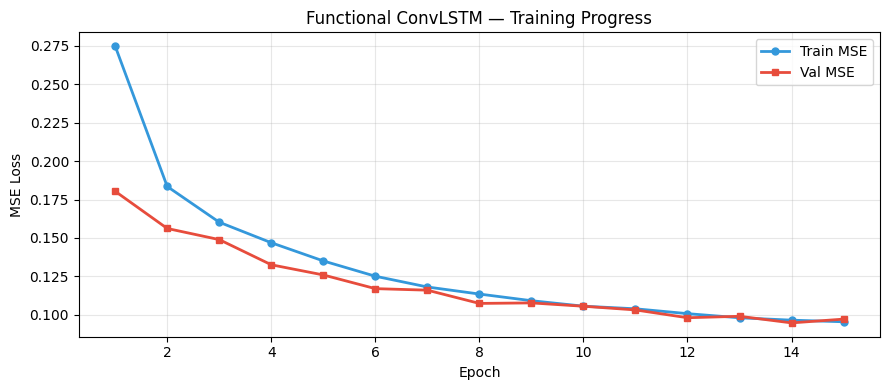

Test MSE  (all pixels)  : 0.12522
Test RMSE (all pixels)  : 0.35387
Test MAE  (all pixels)  : 0.16230
Test MSE  (plume only)  : 0.32053


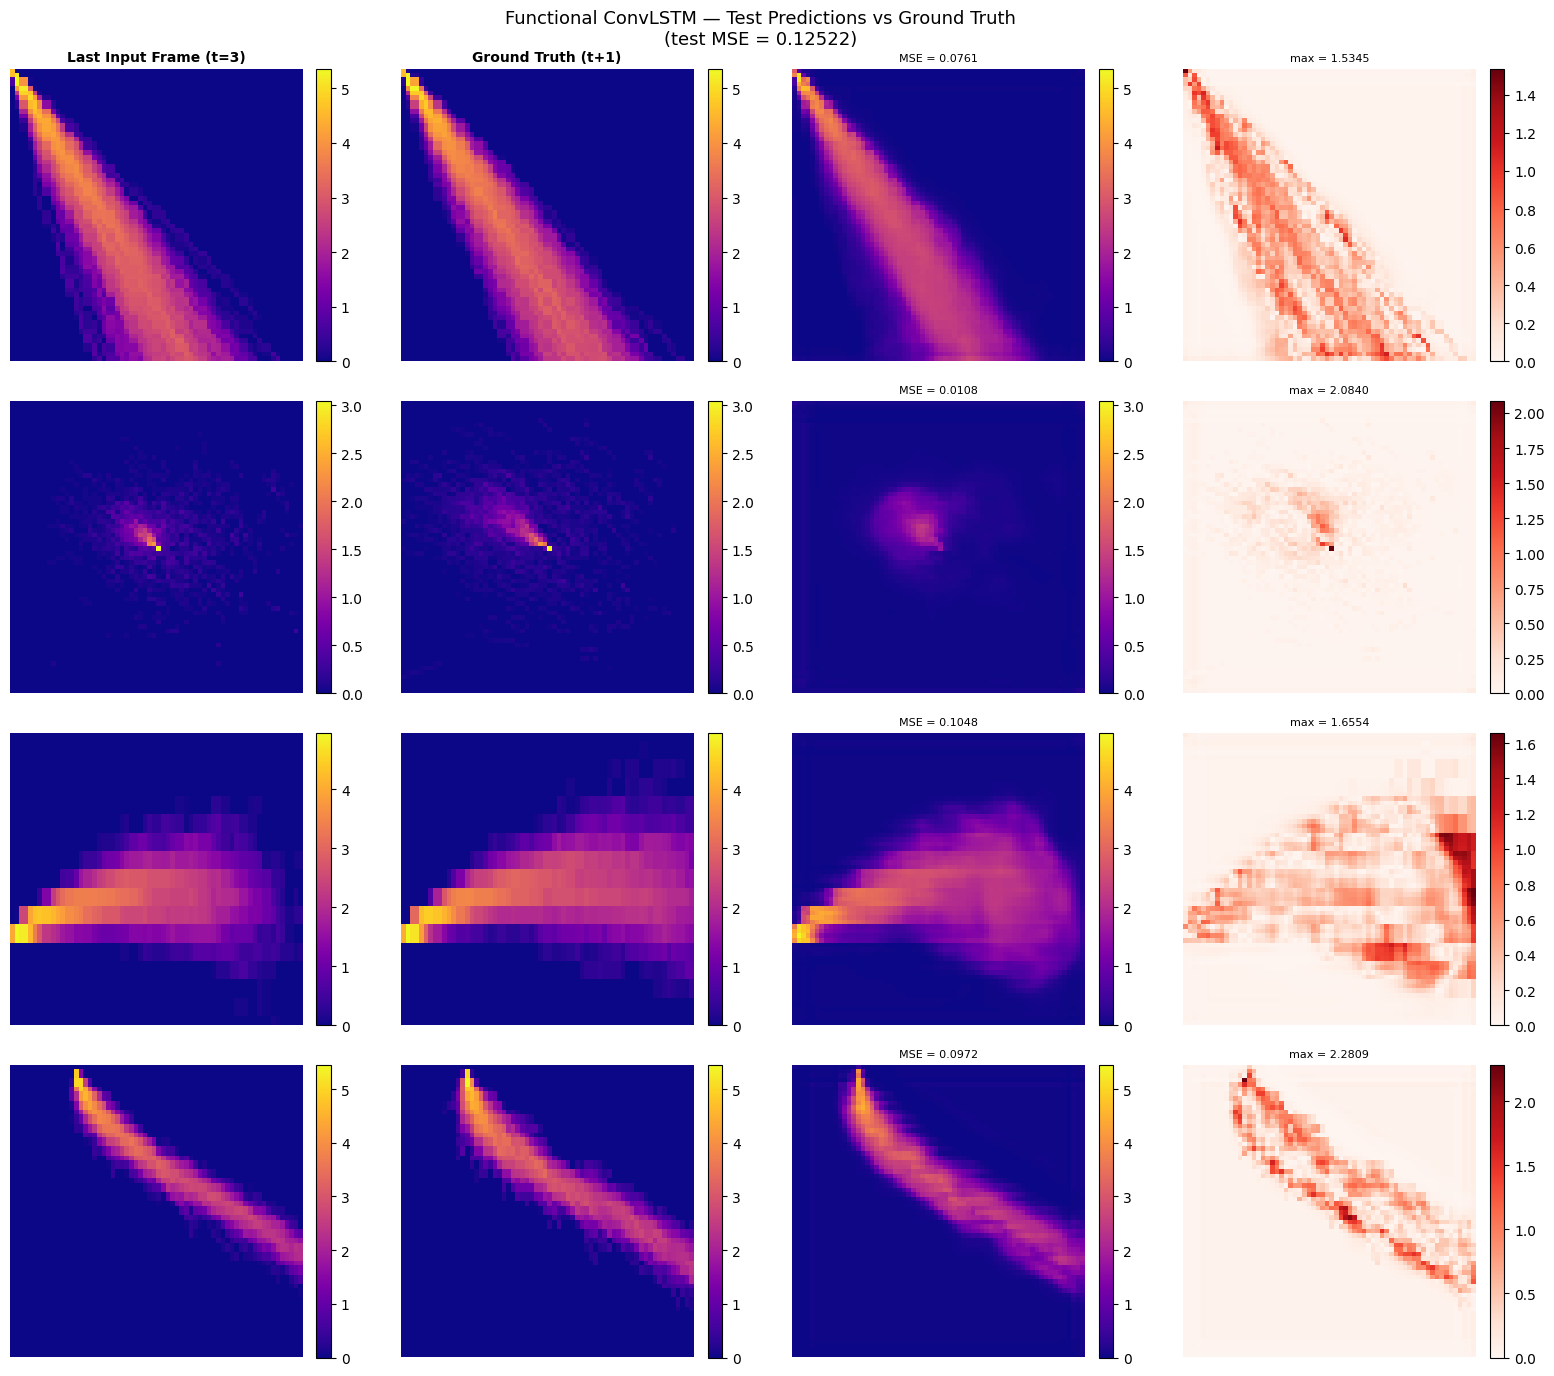

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ── loss curves ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, N_EPOCHS + 1), train_losses, 'o-', label='Train MSE',
        color='#3498db', linewidth=2, markersize=5)
ax.plot(range(1, N_EPOCHS + 1), val_losses,   's-', label='Val MSE',
        color='#e74c3c', linewidth=2, markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Functional ConvLSTM — Training Progress')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── run inference on the test set ─────────────────────────────────────────────
pred_list, tgt_list = [], []
with torch.no_grad():
    for i in range(0, len(X_test), BATCH):
        xb   = X_test[i:i + BATCH].to(device)
        pred = forward(xb, p)[:, 0].cpu().numpy()   # (B, 64, 64)
        pred_list.append(pred)
        tgt_list.append(Y_test[i:i + BATCH].numpy())

preds_np   = np.concatenate(pred_list)    # (N_TEST, 64, 64)
targets_np = np.concatenate(tgt_list)     # (N_TEST, 64, 64)

mse  = mean_squared_error(targets_np.flatten(), preds_np.flatten())
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_np.flatten(), preds_np.flatten())

plume_mask = targets_np.flatten() > 1e-6
mse_plume  = (mean_squared_error(targets_np.flatten()[plume_mask],
                                  preds_np.flatten()[plume_mask])
              if plume_mask.any() else float('nan'))

print(f"Test MSE  (all pixels)  : {mse:.5f}")
print(f"Test RMSE (all pixels)  : {rmse:.5f}")
print(f"Test MAE  (all pixels)  : {mae:.5f}")
print(f"Test MSE  (plume only)  : {mse_plume:.5f}")

# ── visual comparison: 4 random test samples ──────────────────────────────────
N_VIS   = 4
vis_idx = random.sample(range(len(preds_np)), N_VIS)

fig, axes = plt.subplots(N_VIS, 4, figsize=(16, N_VIS * 3.5), squeeze=False)
fig.suptitle(
    f"Functional ConvLSTM — Test Predictions vs Ground Truth\n"
    f"(test MSE = {mse:.5f})",
    fontsize=13,
)

for ax, title in zip(axes[0],
                     ['Last Input Frame (t=3)', 'Ground Truth (t+1)',
                      'Prediction (t+1)', '|Error|']):
    ax.set_title(title, fontweight='bold', fontsize=10)

for row, idx in enumerate(vis_idx):
    # unnormalise the plume channel from the last input frame for display
    last_plume = X_test[idx, -1, 0].numpy() * ch_std[0] + ch_mean[0]
    tgt   = targets_np[idx]
    pred  = preds_np[idx]
    err   = np.abs(pred - tgt)
    vmax  = max(float(tgt.max()), float(pred.max()), 1e-6)
    s_mse = mean_squared_error(tgt.flatten(), pred.flatten())

    for col, (img, cmap, label) in enumerate([
        (last_plume, 'plasma', ''),
        (tgt,        'plasma', ''),
        (pred,       'plasma', f'MSE = {s_mse:.4f}'),
        (err,        'Reds',   f'max = {err.max():.4f}'),
    ]):
        im = axes[row, col].imshow(
            img, cmap=cmap, vmin=0, vmax=(vmax if col < 3 else None)
        )
        plt.colorbar(im, ax=axes[row, col], fraction=0.046, pad=0.04)
        if label:
            axes[row, col].set_title(label, fontsize=8)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

## Reading the results

### Loss curves
- A **decreasing train MSE** means the model is fitting the training data.
- A **val MSE that tracks closely** confirms the model is generalising, not just memorising.
- If val MSE flattens while train keeps dropping → over-fitting. Try fewer epochs, lower LR, or a smaller model.

### Test metrics

| Metric | What it tells you |
|---|---|
| **MSE (all pixels)** | Average squared error including the many zero-background pixels |
| **RMSE** | Same in the original concentration units — easier to interpret |
| **MAE** | Average absolute error — less sensitive to outliers than MSE |
| **MSE (plume only)** | Error only where the true plume is present; the harder, more meaningful number |

### Visualisations
- **Column 1** — the last observed plume frame (t=3), unnormalised for display.
- **Column 2** — the true plume one hour later (the label the model tries to match).
- **Column 3** — what the model predicted. Good predictions look like column 2.
- **Column 4** — absolute error map. Bright = large error, usually at plume edges or high-concentration cores where dispersion is hardest to predict.

### 7 — Export Trained Model

In [31]:
from pathlib import Path

save_path = Path('../src/plume/convlstm_functional_v1.pt')
save_path.parent.mkdir(parents=True, exist_ok=True)

checkpoint = {
    'model_state': {k: v.detach().cpu() for k, v in p.items()},
    'config': {
        'IN_CH':   IN_CH,
        'ENC_CH':  ENC_CH,
        'HID_CH':  HID_CH,
        'DEC_CH':  DEC_CH,
        'K':       K,
        'PAD':     PAD,
        'GN_GRPS': GN_GRPS,
    },
    'normalisation': {
        'ch_mean': ch_mean,
        'ch_std':  ch_std,
    },
    'metrics': {
        'train_mse_final': train_losses[-1],
        'val_mse_final':   val_losses[-1],
        'test_mse_all':    float(mse),
        'test_rmse_all':   float(rmse),
        'test_mae_all':    float(mae),
        'test_mse_plume':  float(mse_plume),
        'epochs':          N_EPOCHS,
    },
    'train_losses': train_losses,
    'val_losses':   val_losses,
}

torch.save(checkpoint, save_path)
print(f"Model saved → {save_path.resolve()}")
print(f"  Parameters : {sum(t.numel() for t in checkpoint['model_state'].values()):,}")
print(f"  Val MSE    : {train_losses[-1]:.5f}  (train)  /  {val_losses[-1]:.5f}  (val)")
print(f"  Test MSE   : {mse:.5f}  (all pixels)  /  {mse_plume:.5f}  (plume only)")

Model saved → C:\Users\joaoh\Documents\GitHub\Geospatial-Forecasting\src\plume\convlstm_functional_v1.pt
  Parameters : 538,145
  Val MSE    : 0.09553  (train)  /  0.09726  (val)
  Test MSE   : 0.12522  (all pixels)  /  0.32053  (plume only)
